In [24]:
import numpy as np
import meep as mp
import matplotlib.pyplot as plt

In [25]:
resolution = 100   # pixels/um

pad = 1           # padding between last hole and PML edge
dpml = 0.6         # PML thickness
radius = 0.45
sx = 2*(dpml + pad + radius)
sy = sx
cell = mp.Vector3(sx,sy,0)
pml_layers = [mp.PML(dpml)]


In [26]:
f_min = 1/0.7 
f_max = 1/0.5
fcen = 0.5*(f_min + f_max)
df = f_max - f_min    # pulse frequency width
nfreq = 100 # number of frequencies at which to compute flux

src = [mp.Source(mp.GaussianSource(fcen, fwidth=df,is_integrated=True),
                     component=mp.Ez,
                     center=mp.Vector3(y=0.5*sy-dpml),
                     size=mp.Vector3(sx,0))]

<Axes: xlabel='X', ylabel='Y'>

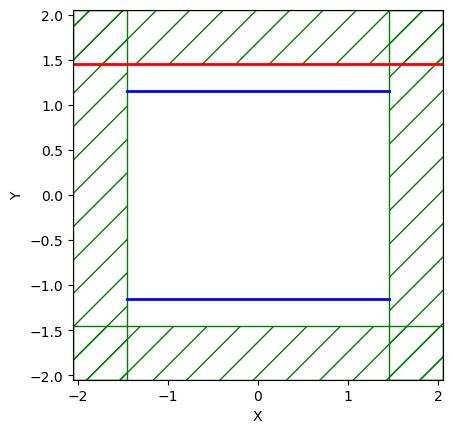

In [27]:
sim = mp.Simulation(cell_size=cell,
                        boundary_layers=pml_layers,
                        sources=src,
                        symmetries=[mp.Mirror(direction=mp.X)],
                        resolution=resolution)

freg = mp.FluxRegion(center=mp.Vector3(y=0.5*sy-dpml-0.3),
                         size=mp.Vector3(x=sx- 2*dpml ))

freg_tr = mp.FluxRegion(center=mp.Vector3(y=-(0.5*sy-dpml-0.3)),
                         size=mp.Vector3(x=sx - 2*dpml ))

refl = sim.add_flux(fcen, df, nfreq, freg)
tran = sim.add_flux(fcen, df, nfreq, freg_tr)

sim.plot2D()

In [28]:

sim.run(#mp.at_every(5,animate),
        until_after_sources=mp.stop_when_fields_decayed(50, mp.Ez, mp.Vector3(y=0.5*sy-dpml-0.5), 1e-3),
)


wvl = 1/np.array(mp.get_flux_freqs(refl))
t0 = mp.get_fluxes(refl)

refl_data = sim.get_flux_data(refl)
sim.reset_meep()

-----------
Initializing structure...
Halving computational cell along direction x
time for choose_chunkdivision = 0.00244446 s
Working in 2D dimensions.
Computational cell is 4.1 x 4.1 x 0 with resolution 100
time for set_epsilon = 0.148926 s
-----------
on time step 6994 (time=34.97), 0.000571967 s/step
field decay(t = 50.005): 0.25065830628281777 / 0.25065830628281777 = 1.0
on time step 13907 (time=69.535), 0.00057863 s/step
field decay(t = 100.01): 2.757232213710834e-16 / 0.25065830628281777 = 1.099996347457901e-15
run 0 finished at t = 100.01 (20002 timesteps)


     cylinder, center = (0,0,0)
          radius 0.45, height 1e+20, axis (0, 0, 1)
          dielectric constant epsilon diagonal = (5.3361,5.3361,5.3361)


<Axes: xlabel='X', ylabel='Y'>

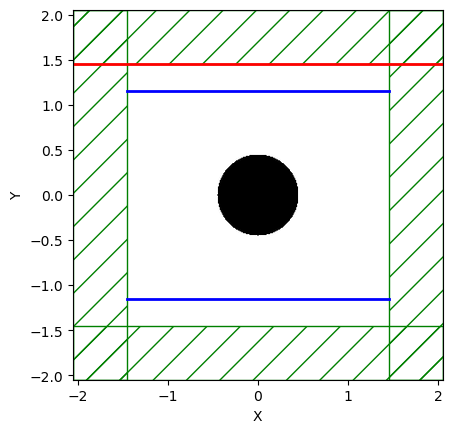

In [30]:
sim.reset_meep()
geometry = [mp.Cylinder(radius=radius,material=mp.Medium(index=2.31))] 

sim = mp.Simulation(cell_size=cell,
                        geometry=geometry,
                        symmetries=[mp.Mirror(direction=mp.X)],
                        boundary_layers=pml_layers,
                        sources=src,
                        resolution=resolution)

    # transmitted flux
refl = sim.add_flux(fcen, df, nfreq, freg)
tran = sim.add_flux(fcen, df, nfreq, freg_tr)

sim.plot2D()

In [7]:
from IPython.display import Video

-----------
Initializing structure...
Halving computational cell along direction x
time for choose_chunkdivision = 0.0012387 s
Working in 2D dimensions.
Computational cell is 4.1 x 4.1 x 0 with resolution 100
     cylinder, center = (0,0,0)
          radius 0.45, height 1e+20, axis (0, 0, 1)
          dielectric constant epsilon diagonal = (5.3361,5.3361,5.3361)
time for set_epsilon = 0.180483 s
-----------


     cylinder, center = (0,0,0)
          radius 0.45, height 1e+20, axis (0, 0, 1)
          dielectric constant epsilon diagonal = (5.3361,5.3361,5.3361)
field decay(t = 10.005): 0.2738333148561604 / 0.2738333148561604 = 1.0
field decay(t = 20.01): 0.209970944730469 / 0.2738333148561604 = 0.7667837817351145
on time step 5400 (time=27), 0.000744963 s/step
field decay(t = 30.015): 0.000972787304251882 / 0.2738333148561604 = 0.003552479743974429
field decay(t = 40.02): 3.3421373327735503e-05 / 0.2738333148561604 = 0.00012205006299285072
field decay(t = 50.025): 3.0182318837938083e-05 / 0.2738333148561604 = 0.00011022150045472845
on time step 10791 (time=53.955), 0.000741983 s/step
field decay(t = 60.03): 2.7784581723684092e-05 / 0.2738333148561604 = 0.00010146530833284044
field decay(t = 70.035): 2.6642648386218414e-05 / 0.2738333148561604 = 9.729513152997219e-05
Normalizing field data...
run 0 finished at t = 70.035 (14007 timesteps)
Generating MP4...


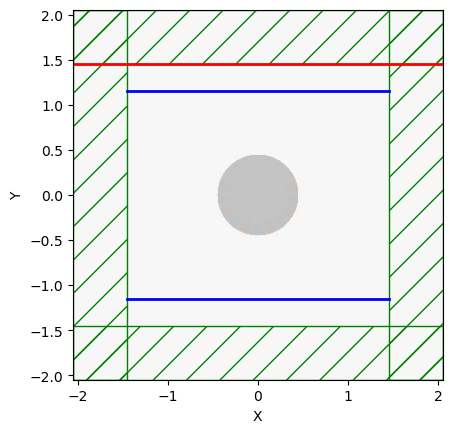

In [31]:
sim.load_minus_flux_data(refl, refl_data)

animate = mp.Animate2D(fields=mp.Ez, realtime=False, normalize=True,vmax=0.001,vmin=-0.001) #Meep object for animating fields

sim.run(mp.at_every(1,animate),
        until_after_sources=mp.stop_when_fields_decayed(10, mp.Ez, mp.Vector3(y=0.5*sy-dpml-0.5), 1e-4),
)

filename = "mie_cylinder.mp4"
animate.to_mp4(4, filename)
Video(filename) #generates the video and saves it under the given filename

Text(0, 0.5, 'Reflectance')

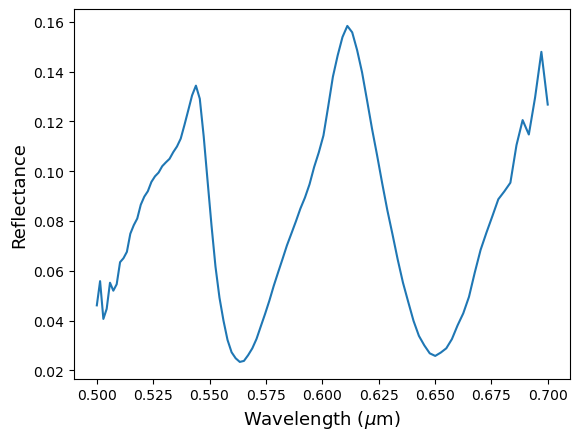

In [33]:
rg= np.array(mp.get_fluxes(refl))
tg= np.array(mp.get_fluxes(tran))

reflectance = -rg/np.array(t0)
transmittance = tg/np.array(t0)

plt.plot(wvl,reflectance)
plt.xlabel('Wavelength ($\mu$m)',fontsize=13)
plt.ylabel('Reflectance',fontsize=13)

___

## Same disc but under periodic boundary condition

In [11]:
sim.reset_meep()

In [12]:
resolution = 100   # pixels/um

pad = 0.2           # padding between last hole and PML edge
dpml = 0.6         # PML thickness
radius = 0.45
sx = 2*(dpml + pad + radius)
sy = 1.5*sx
cell = mp.Vector3(sx,sy,0)
pml_layers = [mp.PML(dpml, direction=mp.Y)]

<Axes: xlabel='X', ylabel='Y'>

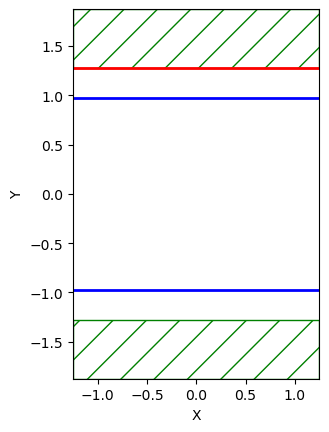

In [13]:
f_min = 1/0.8
f_max = 1/0.5
fcen = 0.5*(f_min + f_max)
df = f_max - f_min    # pulse frequency width
nfreq = 200 # number of frequencies at which to compute flux

src = [mp.Source(mp.GaussianSource(fcen, fwidth=df,is_integrated=True),
                     component=mp.Ez,
                     center=mp.Vector3(y=0.5*sy-dpml),
                     size=mp.Vector3(sx,0))]

sim = mp.Simulation(cell_size=cell,
                        boundary_layers=pml_layers,
                        sources=src,
                        symmetries=[mp.Mirror(direction=mp.X)],
                        resolution=resolution)

freg = mp.FluxRegion(center=mp.Vector3(y=0.5*sy-dpml-0.3),
                         size=mp.Vector3(x=sx ))

freg_tr = mp.FluxRegion(center=mp.Vector3(y=-(0.5*sy-dpml-0.3)),
                         size=mp.Vector3(x=sx  ))

refl = sim.add_flux(fcen, df, nfreq, freg)
tran = sim.add_flux(fcen, df, nfreq, freg_tr)

sim.plot2D()

In [14]:

sim.run(#mp.at_every(5,animate),
        until_after_sources=mp.stop_when_fields_decayed(50, mp.Ez, mp.Vector3(y=0.5*sy-dpml-0.5), 1e-3),
)


wvl = 1/np.array(mp.get_flux_freqs(refl))
t0 = mp.get_fluxes(refl)

refl_data = sim.get_flux_data(refl)
sim.reset_meep()

-----------
Initializing structure...
Halving computational cell along direction x
time for choose_chunkdivision = 0.00190736 s
Working in 2D dimensions.
Computational cell is 2.5 x 3.75 x 0 with resolution 100
time for set_epsilon = 0.0804454 s
-----------
field decay(t = 50.005): 0.472183559643866 / 0.472183559643866 = 1.0
on time step 13084 (time=65.42), 0.000305718 s/step
field decay(t = 100.01): 0.00022447004563506398 / 0.472183559643866 = 0.0004753872536442513
run 0 finished at t = 100.01 (20002 timesteps)


     cylinder, center = (0,0,0)
          radius 0.45, height 1e+20, axis (0, 0, 1)
          dielectric constant epsilon diagonal = (5.3361,5.3361,5.3361)


<Axes: xlabel='X', ylabel='Y'>

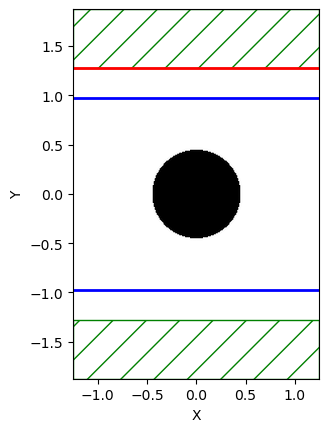

In [15]:
sim.reset_meep()
geometry = [mp.Cylinder(radius=radius,material=mp.Medium(index=2.31))] #mp.Medium(epsilon=eps))]

sim = mp.Simulation(cell_size=cell,
                        geometry=geometry,
                        symmetries=[mp.Mirror(direction=mp.X)],
                        boundary_layers=pml_layers,
                        sources=src,
                        resolution=resolution)

    # transmitted flux
refl = sim.add_flux(fcen, df, nfreq, freg)
tran = sim.add_flux(fcen, df, nfreq, freg_tr)

sim.plot2D()

-----------
Initializing structure...
Halving computational cell along direction x
time for choose_chunkdivision = 0.00178108 s
Working in 2D dimensions.
Computational cell is 2.5 x 3.75 x 0 with resolution 100
     cylinder, center = (0,0,0)
          radius 0.45, height 1e+20, axis (0, 0, 1)
          dielectric constant epsilon diagonal = (5.3361,5.3361,5.3361)
time for set_epsilon = 0.116064 s
-----------
     cylinder, center = (0,0,0)
          radius 0.45, height 1e+20, axis (0, 0, 1)
          dielectric constant epsilon diagonal = (5.3361,5.3361,5.3361)
field decay(t = 10.005): 0.33074792792605195 / 0.33074792792605195 = 1.0
on time step 3000 (time=15), 0.00133392 s/step
field decay(t = 20.01): 0.2945681388630519 / 0.33074792792605195 = 0.8906121973617047
field decay(t = 30.015): 0.004113169896169613 / 0.33074792792605195 = 0.0124359657276197
on time step 6276 (time=31.38), 0.00122107 s/step
field decay(t = 40.02): 0.0003855472981925055 / 0.33074792792605195 = 0.00116568318540

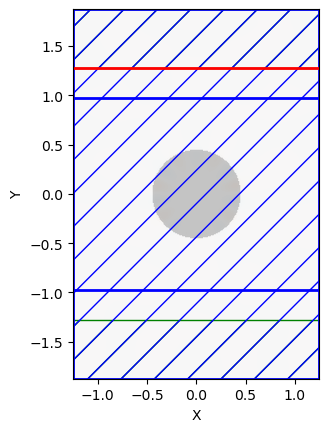

In [16]:
sim.load_minus_flux_data(refl, refl_data)

animate = mp.Animate2D(fields=mp.Ez, realtime=False, normalize=True,vmax=0.001,vmin=-0.001) #Meep object for animating fields

dft_field_probe = sim.add_dft_fields([mp.Ez], fcen, df,nfreq,where=mp.Volume(size=mp.Vector3(sx,sy,0 )) ) #reflected field's dft

sim.run(mp.at_every(1,animate),
        until_after_sources=mp.stop_when_fields_decayed(10, mp.Ez, mp.Vector3(y=0.5*sy-dpml-0.5), 1e-4),
)

filename = "mie_cylinder_periodic.mp4"
animate.to_mp4(4, filename)
Video(filename) #generates the video and saves it under the given filename

In [17]:
Ez_fields = []
for i in range(nfreq):
    Ez_fields.append(sim.get_dft_array(dft_field_probe,mp.Ez,i))

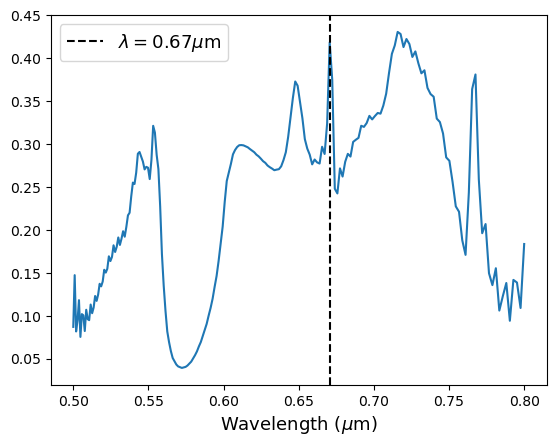

In [23]:
rg= np.array(mp.get_fluxes(refl))
tg= np.array(mp.get_fluxes(tran))

reflectance = -rg/np.array(t0)
transmittance = tg/np.array(t0)

plt.plot(wvl,reflectance)
#plt.plot(1/wvl,transmittance)
plt.xlabel('Wavelength ($\mu$m)',fontsize=13)
plt.axvline(x=0.6706,color='black',linestyle='--',label='$\lambda=0.67\mu$m')
plt.legend(fontsize=13)

In [ ]:
np.argmin(np.abs(wvl-0.6706))

(np.int64(64), np.float64(0.6705981465880371))

Text(0.5, 1.0, '$|E_z|^2$ at wavelength : $\\lambda=0.6705981465880371$')

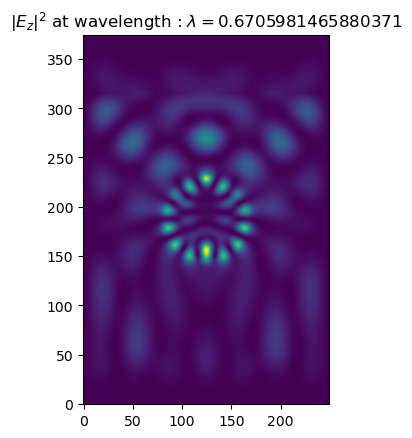

In [ ]:
idx = 64
wvl_ = wvl[idx]
plt.imshow((np.abs(Ez_fields[idx])**2).T,origin='lower')
plt.title('$|E_z|^2$ at wavelength : $\lambda={wl}$'.format(wl=wvl_))